# Ladder Bottom — a quantitative teardown 🔬
### The loose-vs-strict detector split · downtrend-matched base rate · Bonferroni across 4 horizons · a label-shuffle placebo · costs · a synthetic planted-bounce control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_downtrend_base_rate%3F: Mixed](https://img.shields.io/badge/Beats_a_downtrend_base_rate%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The ladder bottom is a specific, mechanical five-candle claim — the job here is to encode it precisely, in two honesty-graded cuts, and grade both against a fair base rate with a multiple-comparisons correction.

> ⚠️ **Data note.** 61 names (SPY + 60 long-listed US large-caps), yfinance daily, ~25 years each (383,080 bars total), as-of 2026-06-30. Reversal bet is long-only against a matching downtrend base rate, entered at the next open (one documented lag). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `85f86a841de4` sample / `9693c3ea7807` panel).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ladder_bottom import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real() if HAVE_REAL else None
print("real cache present:", HAVE_REAL, "| basket size:", len(data.BASKET))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_names': 61, 'years': 25.0, 'total_bars': 383080, 'asof': '2026-06-30', 'fp_spy': '85f86a841de4', 'fp_panel': '9693c3ea7807', 'n_loose': 2543, 'n_strict': 81, 'bonferroni_crit': 2.5, 'loose': {1: (2543, -3.8, 47.2, 2.7, -6.5, -1.87, 0.981, -13.8), 5: (2543, 46.6, 56.2, 27.5, 19.1, 2.24, 0.009, 36.6), 10: (2543, 54.5, 56.2, 55.5, -1.0, -0.08, 0.528, 44.5), 20: (2543, 154.7, 59.9, 120.0, 34.8, 2.12, 0.011, 144.7)}, 'strict': {1: (81, -13.2, 43.2, -15.9, -0.71, 0.805, -23.2), 5: (81, 107.8, 55.6, 80.3, 1.52, 0.045, 97.8), 10: (81, 129.5, 53.1, 74.0, 1.11, 0.109, 119.5), 20: (81, 339.8, 64.2, 219.8, 2.3, 0.006, 329.8)}, 'strict_events': [('NKE', '2026-03-10', '2026-03-16', -2028.9), ('LMT', '2003-01-16', '2003-01-23', -1233.2), ('BA', '2009-02-26', '2009-03-04', 2128.7), ('KMB', '2020-03-18', '2020-03-24', 2143.9), ('MS', '2002-10-02', '2002-10-08', 3973.3)], 'syn_null_mean': 0.02, 'syn_null_sd': 0.97, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_edge_002_t': 2.85, 'syn_edge_002_delta': 33.8, 'syn_edge_004_t': 4.02, 'syn_edge_004_delta': 49.2}


real cache present: True | basket size: 61


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | loose cut (n = 2,543): sign flips across horizons, best |Welch t| = 2.24 (5d), short of Bonferroni **2.50**; strict cut (n = 81): best 20d Welch **t = 2.30**, placebo *p* = 0.006, still short |
| **Tradability** | `MIRAGE` | strict pattern ≈ once per 19 ticker-years; where positive, the return survives a 10 bps round trip, so costs are not the binding constraint — event frequency and certification are |
| **Beats a downtrend base rate?** | `MIXED` | strict cut beats the base rate at 3 of 4 horizons (best delta +220 bps at 20d) but doesn't clear the bar; 3 of 5 best/worst events coincide with famous market-wide bottoms |

> 💡 In plain words: this is the rare candlestick teardown that comes *close* — close enough that rounding it down to a flat None feels almost too tidy, and rounding it up to Real would break the desk's own rule.

## 1 · The claim, steelmanned

Let $b_t = \mathbb{1}[c_t < o_t]$ flag a bearish bar. A **loose ladder bottom** confirms at bar $t$ (the fifth candle) iff: (i) a downtrend context, $c_{t-4} < c_{t-4-10}$; (ii) four bearish rungs, $b_{t-4}, b_{t-3}, b_{t-2}, b_{t-1}$; (iii) strictly descending closes, $c_{t-4} > c_{t-3} > c_{t-2} > c_{t-1}$; (iv) a bullish fifth candle, $c_t > o_t$; (v) a reversal break, $c_t > c_{t-1}$. The **strict** cut adds: small lower shadows on rungs $t{-}4..t{-}2$ (committed selling), a longer upper shadow on rung $t{-}1$ than rung $t{-}2$ (the "warning wick"), and a true gap-up, $o_t > c_{t-1}$.

- **H₀ (no signal).** The reversal return equals the *downtrend-matched* base rate (the same long bet on every bar already in a matching downtrend, whether or not the specific shape fired).
- **H₁ (real bottom).** The reversal return **exceeds** the base rate, Welch *t* ≥ 2, surviving a Bonferroni correction across the 4 horizons tested.
- **The honest sample-size rule.** Below **8** pooled events, no *t*-stat is computed.

We find: loose cut, **H₀ not rejected** (sign flips across horizons — the classic "pick a horizon" trap the correction guards against); strict cut, **closest approach to H₁** (20d Welch *t* = 2.30) but still short of the Bonferroni bar.

## 2 · So what? — inference design

Two honesty problems stack here, the same shape sibling study 685 faces. **First, the base rate must be matched to context, not just "any day"** — a bar already sitting in a downtrend has its own mean-reversion tendency independent of the five-candle shape; comparing the ladder to *any random bar* would credit the pattern with ordinary downtrend bounce-back that has nothing to do with its geometry. **Second, four horizons means four simultaneous looks** at the same question; at the usual *α* = 5% one spurious hit is expected roughly every 20 independent tries, so we apply a **Bonferroni correction** (k = 4, critical |*t*| ≥ **2.50**) — the same discipline siblings 186 and 685 use. The decisive statistic is a **Welch *t*** of the ladder reversal mean against the downtrend base-rate mean (never a one-sample *t* against zero, which would just measure the basket's drift).

## 3 · How we'd know — the protocol

- **Universe.** SPY + 60 long-listed US large-caps, yfinance daily, ~25y each (383,080 bars total), as-of 2026-06-30.
- **Detector, two cuts.** Loose (4 declining candles + downtrend + bullish break) and strict (+ committed rungs, warning wick, gap-up) — reported side by side.
- **Entry.** the open one session after the fifth candle (one documented lag); hold 1/5/10/20 days.
- **Benchmark.** the downtrend-matched base rate — the same long bet on every bar already sitting in a matching downtrend context.
- **Tests.** Welch *t* of ladder vs base-rate mean (decisive); one-sample HAC *t* where n permits; a 2,000-draw label-shuffle placebo; Bonferroni across 4 horizons; below 8 events, no test at all.
- **Costs.** 5 bps one-way, 10 bps round trip, long-only, no borrow.
- **Control.** synthetic panel, forced 5-bar ladder blocks (engineered downtrend + 4 declining candles + 1 reversal candle), planted post-block bounce knob `edge`; the null must not fire across 20 seeds; a planted edge must light up.

## 4 · The teardown

### 4a · The detector — loose vs strict, and why it matters

The pattern's reputation for rarity is earned once the full geometry is required.

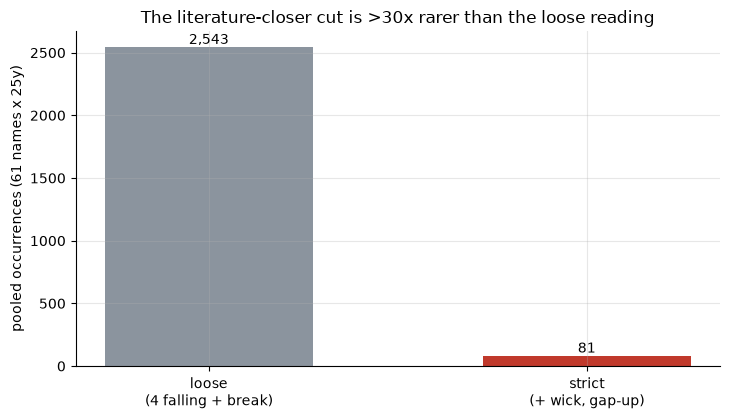

loose=2,543  strict=81


In [2]:
if HAVE_REAL:
    ev = st.pool_events(PANEL)
    n_loose, n_strict = len(ev), int(ev['strict'].sum())
else:
    n_loose, n_strict = R['n_loose'], R['n_strict']
fig, ax = plt.subplots(figsize=(7.4, 4.3))
ax.bar(['loose\n(4 falling + break)', 'strict\n(+ wick, gap-up)'], [n_loose, n_strict],
       color=[GREY, RED], width=.55)
for i,v in enumerate([n_loose, n_strict]): ax.annotate(f'{v:,}',(i,v),ha='center',va='bottom')
ax.set_ylabel(f'pooled occurrences ({R["n_names"]} names x {R["years"]:.0f}y)')
ax.set_title('The literature-closer cut is >30x rarer than the loose reading')
plt.tight_layout(); plt.show()
print(f'loose={n_loose:,}  strict={n_strict}')

> 💡 In plain words: **2,543** vs **81**. The warning-wick-plus-gap requirement — the part of the definition that actually encodes "buyers are fighting back before the reversal prints" — is doing almost all of the rarity work.

### 4b · The loose cut — a sign that flips across horizons

Welch *t* of the ladder reversal mean vs the downtrend-matched base-rate mean, at each horizon, against the Bonferroni-corrected critical value.

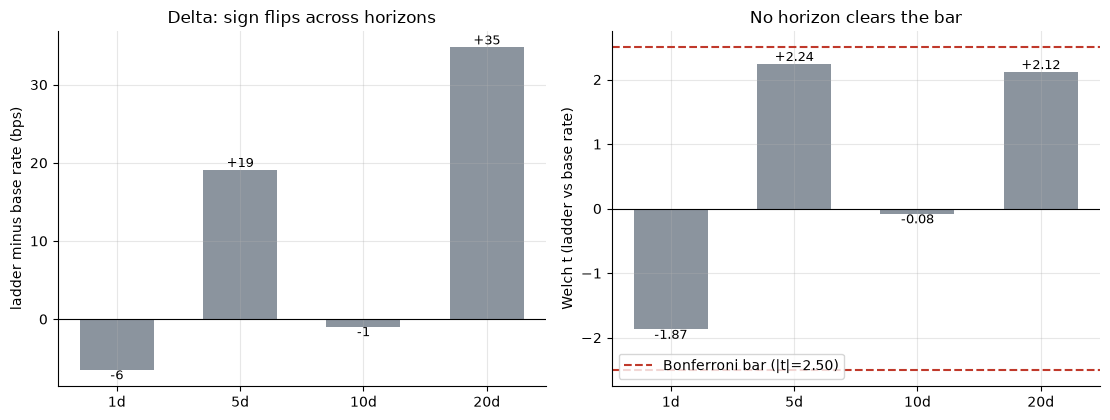

deltas (bps): [-6.5, 19.1, -1.0, 34.8]
welch t: [-1.87, 2.24, -0.08, 2.12]


In [3]:
hs = list(st.HORIZONS)
if HAVE_REAL:
    res = st.run_experiment(PANEL)
    ts = [res['per_horizon'][h]['welch_t'] for h in hs]
    deltas = [res['per_horizon'][h]['delta_bps'] for h in hs]
    crit = res['bonferroni_crit']
else:
    ts = [R['loose'][h][5] for h in hs]; deltas = [R['loose'][h][4] for h in hs]
    crit = R['bonferroni_crit']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.3))
a1.bar([f'{h}d' for h in hs], deltas, color=GREY, width=.6)
a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(deltas): a1.annotate(f'{v:+.0f}',(i,v),ha='center',
    va='top' if v<0 else 'bottom',fontsize=9)
a1.set_ylabel('ladder minus base rate (bps)'); a1.set_title('Delta: sign flips across horizons')
a2.bar([f'{h}d' for h in hs], ts, color=GREY, width=.6)
a2.axhline(-crit, ls='--', c=RED, label=f'Bonferroni bar (|t|={crit:.2f})')
a2.axhline(crit, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(ts): a2.annotate(f'{v:+.2f}',(i,v),ha='center',
    va='top' if v<0 else 'bottom',fontsize=9)
a2.set_ylabel('Welch t (ladder vs base rate)'); a2.set_title('No horizon clears the bar')
a2.legend(); plt.tight_layout(); plt.show()
print('deltas (bps):', [round(d,1) for d in deltas]); print('welch t:', [round(t,2) for t in ts])

> 💡 In plain words: negative at 1 day (*t* = -1.87), positive at 5 (*t* = 2.24), flat at 10 (*t* = -0.08), positive again at 20 (*t* = 2.12). Two of four nominally clear a naive |*t*| ≥ 2 — precisely the kind of result the Bonferroni correction exists to catch: with four independent looks, chance alone produces roughly this many marginal hits. A genuine, persistent edge should not flip sign between its own horizons.

### 4c · The strict cut — closer, and directionally coherent

Same test, the literature-closer geometry. n = 81 — small enough that the placebo and the individual event list both matter as much as the *t*-stat.

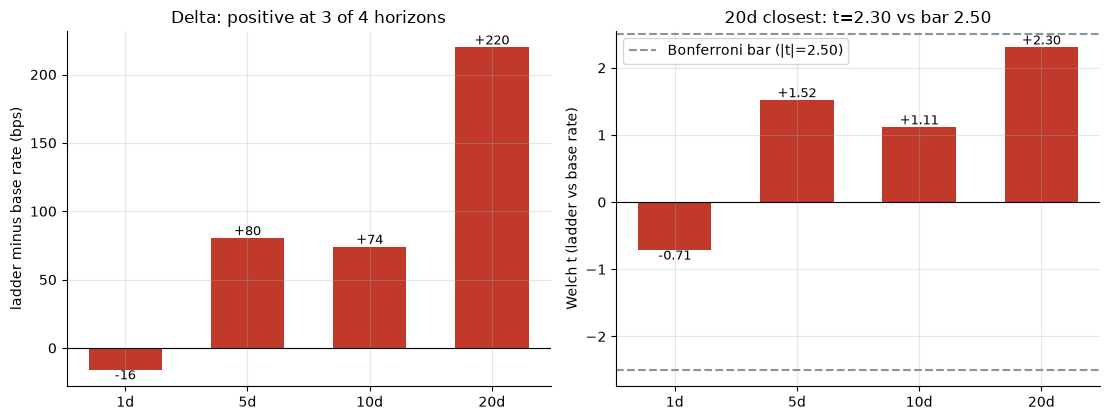

deltas (bps): [-15.9, 80.3, 74.0, 219.8]
welch t: [-0.71, 1.52, 1.11, 2.3]


In [4]:
hs = list(st.HORIZONS)
if HAVE_REAL:
    res = st.run_experiment(PANEL)
    ts = [res['strict_per_horizon'][h]['welch_t'] for h in hs]
    deltas = [res['strict_per_horizon'][h]['delta_bps'] for h in hs]
    crit = res['bonferroni_crit']
else:
    ts = [R['strict'][h][4] for h in hs]; deltas = [R['strict'][h][3] for h in hs]
    crit = R['bonferroni_crit']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.3))
a1.bar([f'{h}d' for h in hs], deltas, color=RED, width=.6)
a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(deltas): a1.annotate(f'{v:+.0f}',(i,v),ha='center',
    va='top' if v<0 else 'bottom',fontsize=9)
a1.set_ylabel('ladder minus base rate (bps)'); a1.set_title('Delta: positive at 3 of 4 horizons')
a2.bar([f'{h}d' for h in hs], ts, color=RED, width=.6)
a2.axhline(-crit, ls='--', c=GREY, label=f'Bonferroni bar (|t|={crit:.2f})')
a2.axhline(crit, ls='--', c=GREY); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(ts): a2.annotate(f'{v:+.2f}',(i,v),ha='center',
    va='top' if v<0 else 'bottom',fontsize=9)
a2.set_ylabel('Welch t (ladder vs base rate)'); a2.set_title(f'20d closest: t={ts[-1]:.2f} vs bar {crit:.2f}')
a2.legend(); plt.tight_layout(); plt.show()
print('deltas (bps):', [round(d,1) for d in deltas]); print('welch t:', [round(t,2) for t in ts])

> 💡 In plain words: the strict cut's 20-day Welch *t* = **2.30** is the study's closest brush with certification — short of the **2.50** bar by less than 0.2, on n = 81 events. That is genuinely suggestive and genuinely not enough: with a sample this small, one or two outsized events (see 4e) can move the mean by hundreds of basis points.

### 4d · The label-shuffle placebo

Draw a same-size random set of bars from the downtrend base-rate pool 2,000 times; the placebo *p* is the share of draws whose mean beats the observed ladder mean.

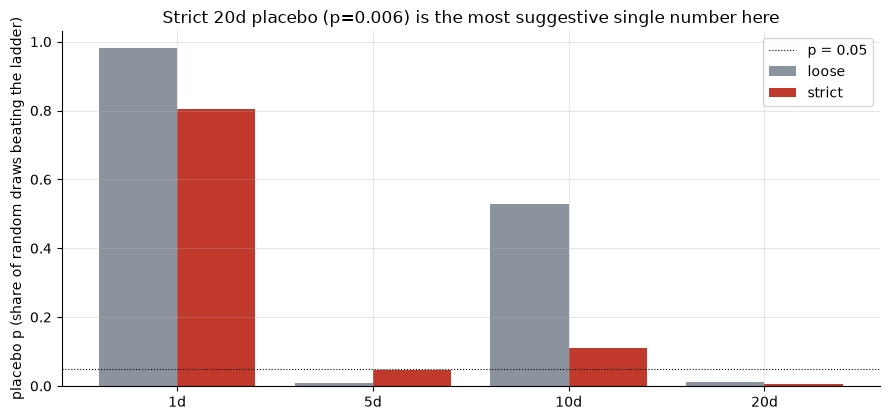

placebo p, loose: {1: 0.981, 5: 0.009, 10: 0.528, 20: 0.011}
placebo p, strict: {1: 0.805, 5: 0.045, 10: 0.109, 20: 0.006}


In [5]:
hs = list(st.HORIZONS)
ps_loose = [R['loose'][h][6] for h in hs]
ps_strict = [R['strict'][h][5] for h in hs]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
x = np.arange(len(hs))
ax.bar(x-.2, ps_loose, .4, color=GREY, label='loose')
ax.bar(x+.2, ps_strict, .4, color=RED, label='strict')
ax.axhline(0.05, c='k', lw=.8, ls=':', label='p = 0.05')
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('placebo p (share of random draws beating the ladder)')
ax.set_title('Strict 20d placebo (p=0.006) is the most suggestive single number here')
ax.legend(); plt.tight_layout(); plt.show()
print('placebo p, loose:', dict(zip(hs, ps_loose)))
print('placebo p, strict:', dict(zip(hs, ps_strict)))

> 💡 In plain words: at 20 days, only **0.6%** of random same-size draws from the downtrend pool beat the actual strict ladder-bottom mean — genuinely rare under the null. The placebo and the Welch test tell a consistent story (both point toward 20d being the study's best evidence), which is reassuring about the machinery — it just isn't reassuring enough to certify the claim once the multiple-horizon correction is applied.

### 4e · The strict cut's event list — where the mean actually comes from

With n = 81, individual events matter. The five most extreme 20-day outcomes:

In [6]:
for tkr, d0, d1, r20 in R['strict_events']:
    print(f'{tkr}: block {d0} -> {d1}   20d {r20/100:+.1f}%')

NKE: block 2026-03-10 -> 2026-03-16   20d -20.3%
LMT: block 2003-01-16 -> 2003-01-23   20d -12.3%
BA: block 2009-02-26 -> 2009-03-04   20d +21.3%
KMB: block 2020-03-18 -> 2020-03-24   20d +21.4%
MS: block 2002-10-02 -> 2002-10-08   20d +39.7%


MS (October 2002), BA (Feb–Mar 2009) and KMB (March 2020) landed right at, or days before, textbook broad-market bottoms; LMT (2003) and NKE (2026) fired mid-decline with no rescue in sight. That mix — some of the biggest wins riding a genuine market-wide turn, not obviously the five-candle geometry on its own — is exactly the kind of confound a larger sample would need to resolve, and precisely why n = 81 can suggest without certifying.

### 4f · Costs

5 bps one-way, 10 bps round trip, long-only. Where the point estimate is positive it survives costs — this pattern's binding constraint is certification and frequency, not transaction costs.

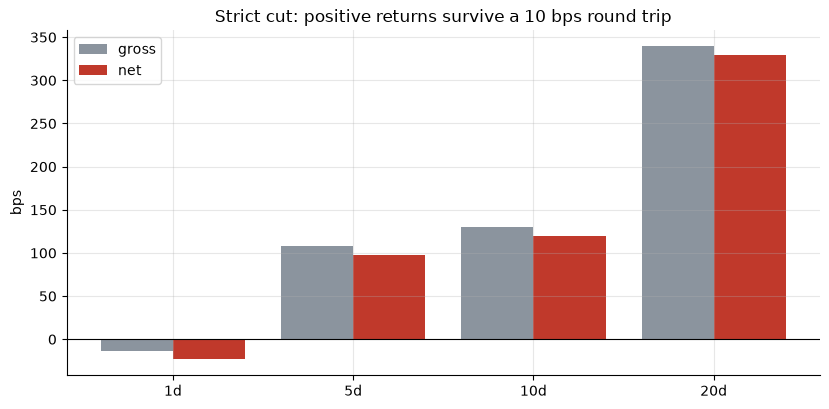

gross: [-13.2, 107.8, 129.5, 339.8]
net: [-23.2, 97.8, 119.5, 329.8]


In [7]:
hs = list(st.HORIZONS)
gross = [R['strict'][h][1] for h in hs]; net = [R['strict'][h][6] for h in hs]
fig, ax = plt.subplots(figsize=(8.4, 4.2))
x = np.arange(len(hs))
ax.bar(x-.2, gross, .4, color=GREY, label='gross'); ax.bar(x+.2, net, .4, color=RED, label='net')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('bps')
ax.set_title('Strict cut: positive returns survive a 10 bps round trip'); ax.legend()
plt.tight_layout(); plt.show()
print('gross:', gross); print('net:', net)

### 4g · Synthetic positive control — the machinery is unbiased

Deterministic panel with forced 5-bar ladder blocks (engineered downtrend, four declining candles, one reversal candle) and a TUNABLE planted bounce. The decisive statistic is the same Welch *t* used on the real tape. The null is checked over **20 seeds** — never a single stream.

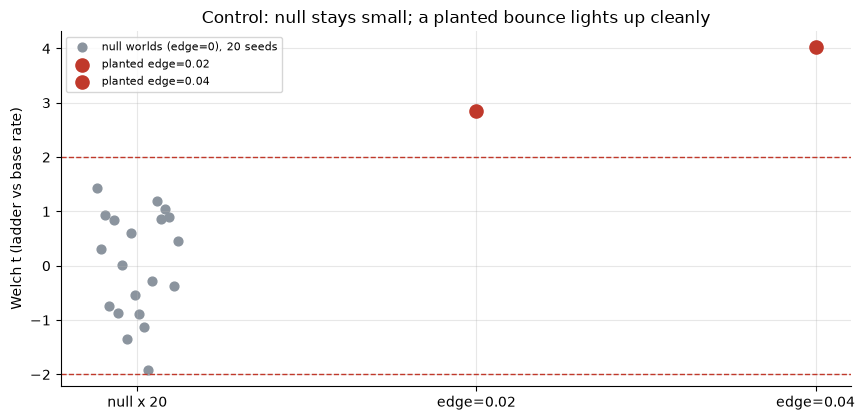

null: mean t = +0.02 (sd 0.97), |t|>=2 in 0/20 seeds
planted edge=0.02: t=+2.85
planted edge=0.04: t=+4.02


In [8]:
null_ts = []
for s_ in range(20):
    d, _t = data.synthetic_panel(edge=0.0, seed=687 + s_)
    r = st.synthetic_detect(d, horizon=20, seed=687 + s_)
    if r['welch_t'] is not None:
        null_ts.append(r['welch_t'])
null_ts = np.asarray(null_ts)
planted = []
for edge in (0.02, 0.04):
    d, _t = data.synthetic_panel(edge=edge, seed=687)
    r = st.synthetic_detect(d, horizon=20, seed=687)
    planted.append((edge, r['welch_t']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(len(null_ts)) + np.linspace(-.12,.12,len(null_ts)), null_ts,
           color=GREY, s=40, label=f'null worlds (edge=0), {len(null_ts)} seeds')
for i,(e,t) in enumerate(planted):
    ax.scatter([i+1], [t], color=RED, s=90, zorder=5,
               label=f'planted edge={e:.2f}')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0]+[i+1 for i in range(len(planted))])
ax.set_xticklabels(['null x ' + str(len(null_ts))] + [f'edge={e:.2f}' for e,_ in planted])
ax.set_ylabel('Welch t (ladder vs base rate)')
ax.set_title('Control: null stays small; a planted bounce lights up cleanly')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/{len(null_ts)} seeds')
for e,t in planted: print(f'planted edge={e:.2f}: t={t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages *t* = +0.02 (sd 0.97) and **never** fires at |*t*| ≥ 2; a planted bounce of just 0.02–0.04 (far smaller than real market swings) lights up cleanly at *t* = +2.85 and +4.02. The machinery is unbiased and has the power to find a real effect of this size. Per the desk's rule, **a synthetic control never backs a Signal stamp** — it only proves the harness would catch a genuine planted effect, which it does. The honest, close-but-short real-tape result above stands on its own.

## 5 · The verdict

- **Signal `NONE`** — the loose cut (n = 2,543) contradicts itself across horizons (negative at 1d, flat at 10d) and no horizon clears the Bonferroni bar (**2.50**). The literature-closer strict cut (n = 81) is directionally coherent and comes closest — 20d Welch *t* = **2.30**, placebo *p* = **0.006** — but still falls short, and its own 1-day reaction is negative.
- **Tradability `MIRAGE`** — the strict pattern fires about once per 19 ticker-years; even the loose cut, far more frequent, fails certification. Where positive, the return survives a 10 bps round trip — costs are not the binding constraint here.
- **"Beats a downtrend base rate?" `MIXED`** — the strict cut beats the base rate at 3 of 4 horizons with an economically large net return (+330 bps at 20d) and a suggestive placebo, but doesn't clear the certification bar, and 3 of its 5 most extreme events coincide with famous *market-wide* bottoms rather than obviously the candle geometry alone. Not busted, not confirmed.

## 6 · Going further

- **A close miss is worth naming precisely.** Rounding this up to Real would break the desk's own multiple-testing discipline; rounding it down to a flat, uninteresting None would hide the strict cut's genuinely consistent direction and suggestive placebo. Both things are true at once, and that tension *is* the finding.
- **The market-bottom confound is the natural next question.** Three of the five most extreme strict events sit at famous, broad drawdown bottoms. A follow-up could condition on a market-wide (not just single-name) downtrend to see whether the ladder's apparent edge concentrates there — which would be a *different*, testable claim from "any stock's ladder bottom marks a turn."
- **Dedup map:** [455-three-methods](../../455-three-methods/) (a different 5-candle shape, a continuation not a reversal, on ETFs), [408-three-black-crows](../../408-three-black-crows/) (the same four falling candles read bearish, shorted — not this study's fifth, reversing candle), [186-morning-star](../../186-morning-star/) (a 3-candle bullish reversal, the same random-baseline/Bonferroni idiom), [685-tri-star-doji](../../685-tri-star-doji/) (three dojis, the strict/loose + `MIN_N_FOR_TEST` discipline this study reuses directly).

*Reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*